In [12]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt

In [15]:
# ── 1. Load Data ──────────────────────────────────────────────
cols = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes",
    "land","wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root","num_file_creations",
    "num_shells","num_access_files","num_outbound_cmds","is_host_login",
    "is_guest_login","count","srv_count","serror_rate","srv_serror_rate",
    "rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate",
    "srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate","label"
]
df = pd.read_csv("corrected.gz", names=cols)
df

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,udp,private,SF,105,146,0,0,0,0,...,254,1.0,0.01,0.00,0.0,0.0,0.0,0.0,0.0,normal.
1,0,udp,private,SF,105,146,0,0,0,0,...,254,1.0,0.01,0.00,0.0,0.0,0.0,0.0,0.0,normal.
2,0,udp,private,SF,105,146,0,0,0,0,...,254,1.0,0.01,0.00,0.0,0.0,0.0,0.0,0.0,normal.
3,0,udp,private,SF,105,146,0,0,0,0,...,254,1.0,0.01,0.00,0.0,0.0,0.0,0.0,0.0,snmpgetattack.
4,0,udp,private,SF,105,146,0,0,0,0,...,254,1.0,0.01,0.01,0.0,0.0,0.0,0.0,0.0,snmpgetattack.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
311024,0,udp,private,SF,105,147,0,0,0,0,...,255,1.0,0.00,0.01,0.0,0.0,0.0,0.0,0.0,normal.
311025,0,udp,private,SF,105,147,0,0,0,0,...,255,1.0,0.00,0.01,0.0,0.0,0.0,0.0,0.0,normal.
311026,0,udp,private,SF,105,147,0,0,0,0,...,255,1.0,0.00,0.01,0.0,0.0,0.0,0.0,0.0,normal.
311027,0,udp,private,SF,105,147,0,0,0,0,...,255,1.0,0.00,0.01,0.0,0.0,0.0,0.0,0.0,normal.


In [27]:
# ── 2. Preprocessing ──────────────────────────────────────────
df['binary_label'] = df['label'].apply(lambda x: 0 if x == 'normal.' else 1)

df['protocol_type'] = pd.Categorical(df['protocol_type']).codes
df['service']       = pd.Categorical(df['service']).codes
df['flag']          = pd.Categorical(df['flag']).codes

X = df.drop(['label', 'binary_label'], axis=1)
y = df['binary_label']
df

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,binary_label
0,0,2,46,9,105,146,0,0,0,0,...,1.0,0.01,0.00,0.0,0.0,0.0,0.0,0.0,normal.,0
1,0,2,46,9,105,146,0,0,0,0,...,1.0,0.01,0.00,0.0,0.0,0.0,0.0,0.0,normal.,0
2,0,2,46,9,105,146,0,0,0,0,...,1.0,0.01,0.00,0.0,0.0,0.0,0.0,0.0,normal.,0
3,0,2,46,9,105,146,0,0,0,0,...,1.0,0.01,0.00,0.0,0.0,0.0,0.0,0.0,snmpgetattack.,1
4,0,2,46,9,105,146,0,0,0,0,...,1.0,0.01,0.01,0.0,0.0,0.0,0.0,0.0,snmpgetattack.,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
311024,0,2,46,9,105,147,0,0,0,0,...,1.0,0.00,0.01,0.0,0.0,0.0,0.0,0.0,normal.,0
311025,0,2,46,9,105,147,0,0,0,0,...,1.0,0.00,0.01,0.0,0.0,0.0,0.0,0.0,normal.,0
311026,0,2,46,9,105,147,0,0,0,0,...,1.0,0.00,0.01,0.0,0.0,0.0,0.0,0.0,normal.,0
311027,0,2,46,9,105,147,0,0,0,0,...,1.0,0.00,0.01,0.0,0.0,0.0,0.0,0.0,normal.,0


In [28]:
# ── 3. Train/Test Split ───────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ── 4. Train Random Forest ────────────────────────────────────
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [22]:
# ════════════════════════════════════════════════════════════════
# OUTPUT 1: Model Metrics
# ════════════════════════════════════════════════════════════════
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["Normal", "Anomaly"]))

Accuracy: 0.9814969617078738
              precision    recall  f1-score   support

      Normal       0.95      0.95      0.95     12004
     Anomaly       0.99      0.99      0.99     50202

    accuracy                           0.98     62206
   macro avg       0.97      0.97      0.97     62206
weighted avg       0.98      0.98      0.98     62206




        OUTPUT 2: CONFUSION MATRIX

 True Negatives  (TN) - Normal correctly identified : 11415
 True Positives  (TP) - Attacks correctly caught     : 49640
  False Positives (FP) - Normal flagged as attack    : 589
 False Negatives (FN) - Attacks that slipped through : 562


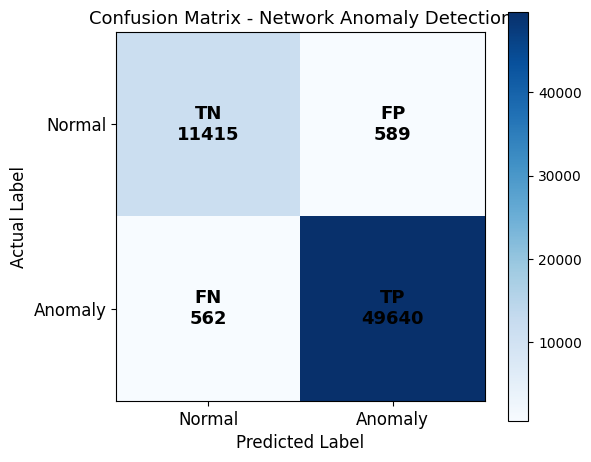

In [19]:
# ════════════════════════════════════════════════════════════════
# OUTPUT 2: Confusion Matrix
# ════════════════════════════════════════════════════════════════
cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

print("\n" + "=" * 55)
print("        OUTPUT 2: CONFUSION MATRIX")
print("=" * 55)
print(f"\n True Negatives  (TN) - Normal correctly identified : {TN}")
print(f" True Positives  (TP) - Attacks correctly caught     : {TP}")
print(f"  False Positives (FP) - Normal flagged as attack    : {FP}")
print(f" False Negatives (FN) - Attacks that slipped through : {FN}")
print("=" * 55)

labels = ["Normal", "Anomaly"]
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(labels, fontsize=12)
ax.set_yticklabels(labels, fontsize=12)

# Add TN, FP, FN, TP labels inside boxes
box_labels = [["TN", "FP"], ["FN", "TP"]]
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{box_labels[i][j]}\n{cm[i][j]}",
                ha='center', va='center', fontsize=13,
                color='black', fontweight='bold')

ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("Actual Label", fontsize=12)
ax.set_title("Confusion Matrix - Network Anomaly Detection", fontsize=13)
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()


        OUTPUT 3: FEATURE IMPORTANCE RANKING

Top 10 Most Important Features:
----------------------------------------
 1. dst_bytes                           → 0.1404
 2. src_bytes                           → 0.1273
 3. count                               → 0.1159
 4. logged_in                           → 0.0905
 5. service                             → 0.0591
 6. dst_host_count                      → 0.0531
 7. dst_host_srv_diff_host_rate         → 0.0480
 8. protocol_type                       → 0.0477
 9. srv_count                           → 0.0434
10. dst_host_same_src_port_rate         → 0.0389


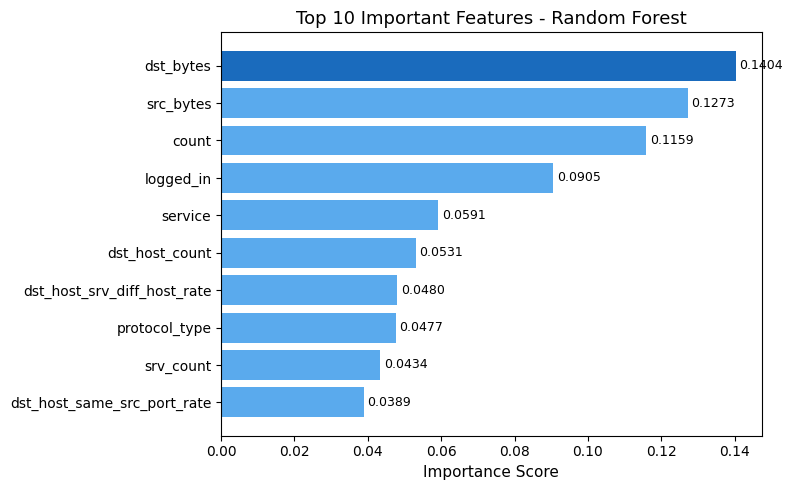

In [24]:
# ════════════════════════════════════════════════════════════════
# OUTPUT 3: Feature Importance Ranking
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 55)
print("        OUTPUT 3: FEATURE IMPORTANCE RANKING")
print("=" * 55)

feature_names = X.columns
importances = pd.Series(model.feature_importances_, index=feature_names)
top10 = importances.nlargest(10).sort_values()

print("\nTop 10 Most Important Features:")
print("-" * 40)
for rank, (feat, score) in enumerate(top10.sort_values(ascending=False).items(), 1):
    print(f"{rank:2}. {feat:35} → {score:.4f}")
print("=" * 55)

plt.figure(figsize=(8, 5))
colors = ['#1a6bbd' if i == len(top10)-1 else '#5aaaed' for i in range(len(top10))]
plt.barh(top10.index, top10.values, color=colors)
plt.title("Top 10 Important Features - Random Forest", fontsize=13)
plt.xlabel("Importance Score", fontsize=11)

for i, (val, name) in enumerate(zip(top10.values, top10.index)):
    plt.text(val + 0.001, i, f"{val:.4f}", va='center', fontsize=9)

plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()
# print(" Feature Importance chart saved as feature_importance.png")

In [25]:
# ════════════════════════════════════════════════════════════════
# OUTPUT 4: Sample Prediction Table
# ════════════════════════════════════════════════════════════════
print("\n" + "=" * 55)
print("        OUTPUT 4: SAMPLE PREDICTION TABLE")
print("=" * 55)

sample = pd.DataFrame({
    'Sample No.'      : range(1, 11),
    'Actual Label'    : ['Normal' if v == 0 else 'Anomaly' for v in y_test[:10]],
    'Predicted Label' : ['Normal' if v == 0 else 'Anomaly' for v in y_pred[:10]],
})
sample['Result'] = sample.apply(
    lambda row: ' Correct' if row['Actual Label'] == row['Predicted Label']
                else ' Wrong', axis=1
)

print("\n", sample.to_string(index=False))
print("\n Summary:")
correct = (sample['Result'] == ' Correct').sum()
print(f"   Correct Predictions : {correct}/10")
print(f"   Wrong Predictions   : {10 - correct}/10")
print("=" * 55)


        OUTPUT 4: SAMPLE PREDICTION TABLE

  Sample No. Actual Label Predicted Label   Result
          1      Anomaly         Anomaly  Correct
          2      Anomaly         Anomaly  Correct
          3      Anomaly         Anomaly  Correct
          4       Normal          Normal  Correct
          5      Anomaly         Anomaly  Correct
          6       Normal          Normal  Correct
          7       Normal          Normal  Correct
          8      Anomaly         Anomaly  Correct
          9       Normal          Normal  Correct
         10      Anomaly         Anomaly  Correct

 Summary:
   Correct Predictions : 10/10
   Wrong Predictions   : 0/10


In [10]:
sample = pd.DataFrame({
    'Sample No.'      : range(1, 11),
    'Actual Label'    : ['Normal' if v == 0 else 'Anomaly' for v in y_test[:10]],
    'Predicted Label' : ['Normal' if v == 0 else 'Anomaly' for v in y_pred[:10]],
})
sample

,Sample No.,Actual Label,Predicted Label
0,1,Anomaly,Anomaly
1,2,Anomaly,Anomaly
2,3,Anomaly,Anomaly
3,4,Normal,Normal
4,5,Anomaly,Anomaly
5,6,Normal,Normal
6,7,Normal,Normal
7,8,Anomaly,Anomaly
8,9,Normal,Normal
9,10,Anomaly,Anomaly
